In [ ]:
# Biblioteki
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import datasets

import keras

from keras import layers
from keras.models import Sequential 
from keras.layers import Dense, Flatten
from tensorflow.keras import layers, models

In [41]:
# Pobieramy zbiór danych CIFAR10 i dzielimy go na zbiór uczący i testowy
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normujemy dane
train_images, test_images = train_images / 255.0, test_images / 255.0

In [42]:
#Jaki wymiar mają te dane
train_images.shape

(50000, 32, 32, 3)

In [43]:
# etykiety klas danych CIFAR10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


### Sieć gęsta

In [44]:
# Inicjalizacja modelu
siec_gesta = Sequential()
siec_gesta.add(Flatten(input_shape=(32, 32, 3)))
siec_gesta.add(Dense(128, activation="relu")) # Dodajemy warstwę gęstą - 128 neuronów
siec_gesta.add(Dense(64, activation="relu")) # Dodajemy warstwę gęstą - 64 neuronów
siec_gesta.add(Dense(10, activation="softmax")) # warstwa wyjściowa

/home/dawid/.local/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


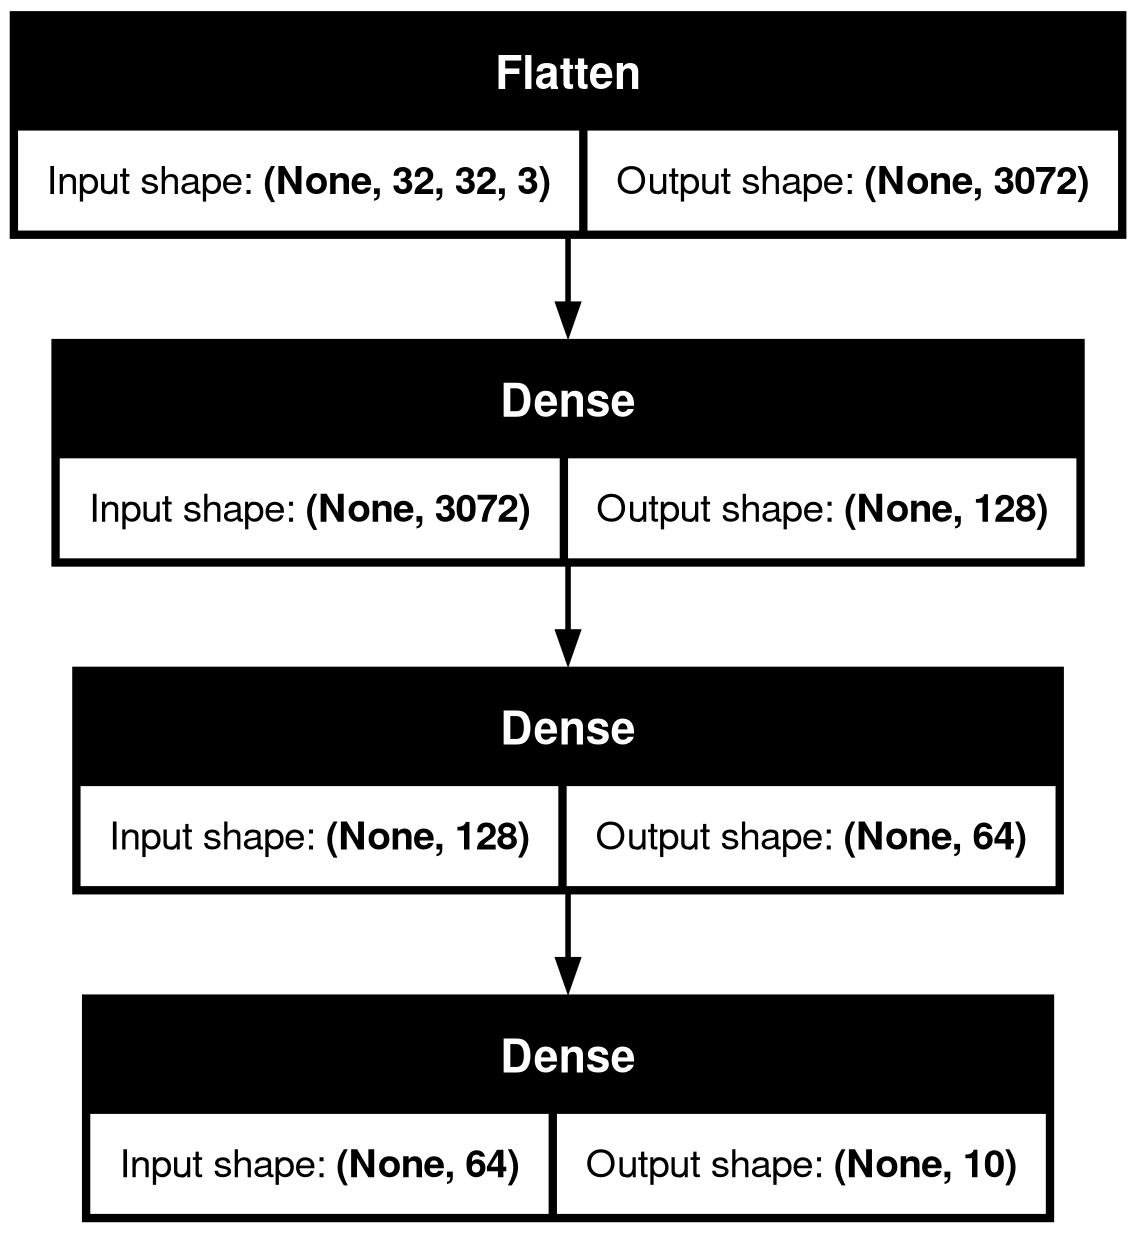

In [45]:
keras.utils.plot_model(siec_gesta,
                       "wymiary_sieci_gestej.png",
                       show_shapes=True)

In [46]:
# Tabela, zawierająca podsumowanie modelu gęstej sieci neuronowej
siec_gesta.summary()

# Liczba parametrów w warstwie = (liczba na wejściu + 1) * liczba na wyjściu

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,250 (1.53 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
# Definiujemy 
# metodę do optymalizacji funkcji celu
# funkcję straty (from_logits=True) - kiedy warstwa wyjściowa nie ma funkcji aktywacji

siec_gesta.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#### Inne metryki
* accuracy - dokładność
* precision - precyzja
* recall - czułość
* tf.keras.metrics.AUC() - pole pod krzywą ROC

In [48]:
# Trenowanie modelu gęstej sieci (dane uczące)
historia_siec_gesta = siec_gesta.fit(train_images, train_labels,
                      epochs=5, batch_size=128,
                      validation_split=0.1)

# validation_split=0.1 to podział danych, podanych w fit(), na zbiór walidacyjny (10% danych) i zbiór do trenowania modelu

Epoch 1/5


/home/dawid/.local/lib/python3.12/site-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.3043 - loss: 1.9381 - val_accuracy: 0.3510 - val_loss: 1.8363
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3733 - loss: 1.7645 - val_accuracy: 0.3738 - val_loss: 1.7713
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4036 - loss: 1.6788 - val_accuracy: 0.3974 - val_loss: 1.6905
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4218 - loss: 1.6232 - val_accuracy: 0.3942 - val_loss: 1.6881
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4364 - loss: 1.5856 - val_accuracy: 0.4272 - val_loss: 1.6100


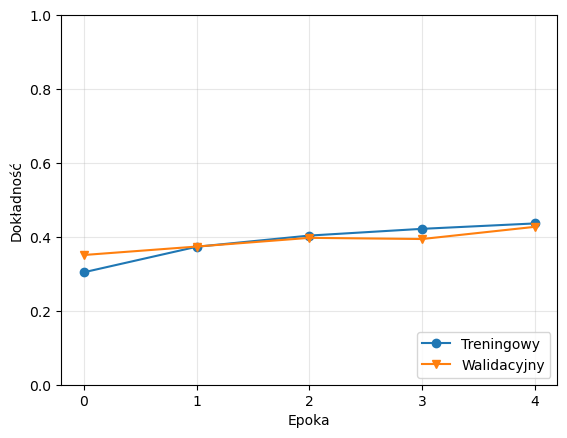

In [66]:
# Wykres dokładności na zbiorze testowym
plt.plot(historia_siec_gesta.history['accuracy'], label='Treningowy', marker = "o")
plt.plot(historia_siec_gesta.history['val_accuracy'], label = 'Walidacyjny', marker = "v")
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.ylim([0, 1])
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.xticks(range(len(historia_siec_gesta.history['accuracy'])))
plt.show()

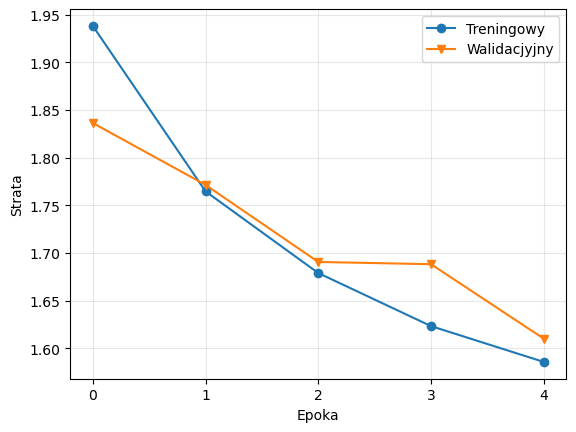

In [67]:
# Wykres funkcji straty
plt.plot(historia_siec_gesta.history['loss'], label='Treningowy', marker='o')
plt.plot(historia_siec_gesta.history['val_loss'], label='Walidacjyjny', marker='v')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.xticks(range(len(historia_siec_gesta.history['loss'])))
plt.show()

In [68]:
# Zapisujemy model gęstej sieci
siec_gesta.save("model_gesta_siec.keras")

# Wczytujemy model sieci z pliku
model_gesta = keras.models.load_model("model_gesta_siec.keras")

### Konwolucyjne sieci neuronowe

In [73]:
# CNN: 1 warstwa splotowa, 1 warstwa pooling
splotowa_1 = Sequential()
splotowa_1.add(layers.Conv2D(36, (3, 3), activation='relu', input_shape=(32, 32, 3)))
splotowa_1.add(layers.MaxPooling2D((2, 2)))
splotowa_1.add(layers.Flatten())
splotowa_1.add(layers.Dense(10, activation="softmax"))

Conv2D - warstwa splotowa

* 36 - liczba filtrów
* (3,3) - wymiar filtra
* input_shape = (32, 32, 3) - wymiary obrazu (32x32), 3 - liczba macierzy (RGB)

MaxPooling2D(2,2) - macierz 2x2 - zwraca wartość największą

In [74]:
splotowa_1.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 36)     │         1,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 36)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 8100)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │        81,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,018 (320.38 KB)

 Trainable params: 82,018 (320.38 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
splotowa_1.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [76]:
# Trening modelu
splotowe_1_historia = splotowa_1.fit(train_images, train_labels,
                     epochs=5, batch_size=128,
                     validation_split=0.1)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.4384 - loss: 1.6119 - val_accuracy: 0.5394 - val_loss: 1.3672
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.5488 - loss: 1.2987 - val_accuracy: 0.5726 - val_loss: 1.2547
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.5816 - loss: 1.2122 - val_accuracy: 0.5848 - val_loss: 1.2094
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.6043 - loss: 1.1498 - val_accuracy: 0.5992 - val_loss: 1.1691
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.6222 - loss: 1.0998 - val_accuracy: 0.6118 - val_loss: 1.1295


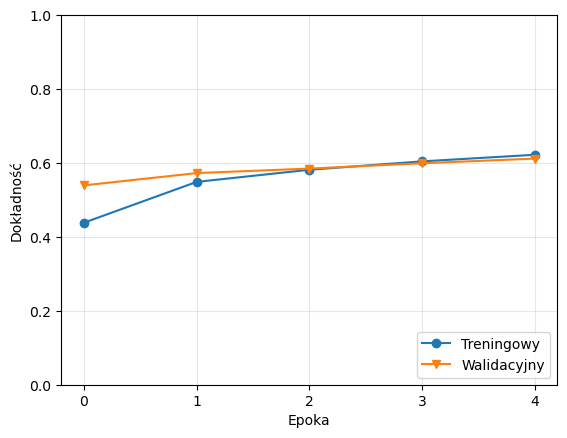

In [77]:
# Wykres dokładności na zbiorze testowym
plt.plot(splotowe_1_historia.history['accuracy'], label='Treningowy', marker = "o")
plt.plot(splotowe_1_historia.history['val_accuracy'], label = 'Walidacyjny', marker = "v")
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.ylim([0, 1])
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.xticks(range(len(splotowe_1_historia.history['accuracy'])))
plt.show()

#### Dodajemy warstwę splotową

In [ ]:
# CNN: 1 warstwa splotowa, 1 warstwa pooling
splotowa_1 = Sequential()
splotowa_1.add(layers.Conv2D(36, (3, 3), activation='relu', input_shape=(32, 32, 3)))
splotowa_1.add(layers.MaxPooling2D((2, 2)))
splotowa_1.add(layers.Flatten())
splotowa_1.add(layers.Dense(10, activation="softmax"))
